# scRNA-seq analysis of PGT differentiation

This notebook analyzes single-cell RNA-seq data from iPSCs, definitive endoderm (DE), and primitive gut tube (PGT) cells.

## Input

The input consists of Poisson-corrected counts from iPSC, DE and PGT samples, available from GEO:
- GSM9145591_iPSCs.barcodes.tsv.gz
- GSM9145591_iPSCs.features.tsv.gz
- GSM9145591_iPSCs.matrix.mtx.gz
- GSM9145592_DE.barcodes.tsv.gz
- GSM9145592_DE.features.tsv.gz
- GSM9145592_DE.matrix.mtx.gz
- GSM9145593_PGT.barcodes.tsv.gz
- GSM9145593_PGT.features.tsv.gz
- GSM9145593_PGT.matrix.mtx.gz

## Output 

- Figure 2c: Harmony layout
- Scanpy object

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation
from statsmodels.stats.multitest import multipletests

# scRNA-seq analysis
import scanpy as sc
import harmony
import palantir

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10))
sns.set_style("ticks")

# Hide warnings
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))

# Versions
sc.logging.print_versions()

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


-----
anndata     0.10.9
scanpy      1.10.3
-----
PIL                         10.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        24.2.0
attrs                       24.2.0
babel                       2.14.0
brotli                      1.1.0
certifi                     2025.11.12
cffi                        1.17.1
charset_normalizer          3.4.0
colorama                    0.4.6
comm                        0.2.2
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0
debugpy                     1.8.7
decorator                   5.1.1
defusedxml                  0.7.1
executing                   2.1.0
fa2                         NA
fastjsonschema              NA
fcsparser                   0.2.8
fqdn                        NA
h5py                        3.11.0
harmony                     0.1.5
idna                        3.10
igraph                      0.11.6
ipyk

## Quality control

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO/scRNA"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = output_dir

# Settings
labels = ["iPSC", "DE", "PGT"]                                     # custom labels
samples = ["GSM9145591_iPSCs", "GSM9145592_DE", "GSM9145593_PGT"]  # base names of count files
colors = ["#264653", "#E9C46A", "#E76F51"]                         # colors to use
palette = dict(zip(labels, colors))                                # palette for plots

In [3]:
def load_adata_qc(sample, label):
    """Load counts and calculate QC metrics."""
    adata = sc.read_mtx(f"{input_dir}/{sample}.matrix.mtx.gz").transpose()
    adata.obs_names = pd.read_csv(f"{input_dir}/{sample}.barcodes.tsv.gz", sep="\t", header=None)[0].tolist()
    adata.var_names = pd.read_csv(f"{input_dir}/{sample}.features.tsv.gz", sep="\t", header=None)[1].tolist()
    adata.var_names_make_unique()
    
    adata.var["mt"] = adata.var_names.str.upper().str.startswith(("MT-"))
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS","RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt","ribo","hb"], inplace=True, percent_top=[20], log1p=True)

    adata.obs["Celltype"] = label
    
    return adata

adatas = [load_adata_qc(sample, label) for sample, label in zip(samples, labels)]
print(adatas)

[AnnData object with n_obs × n_vars = 375 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', AnnData object with n_obs × n_vars = 373 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_

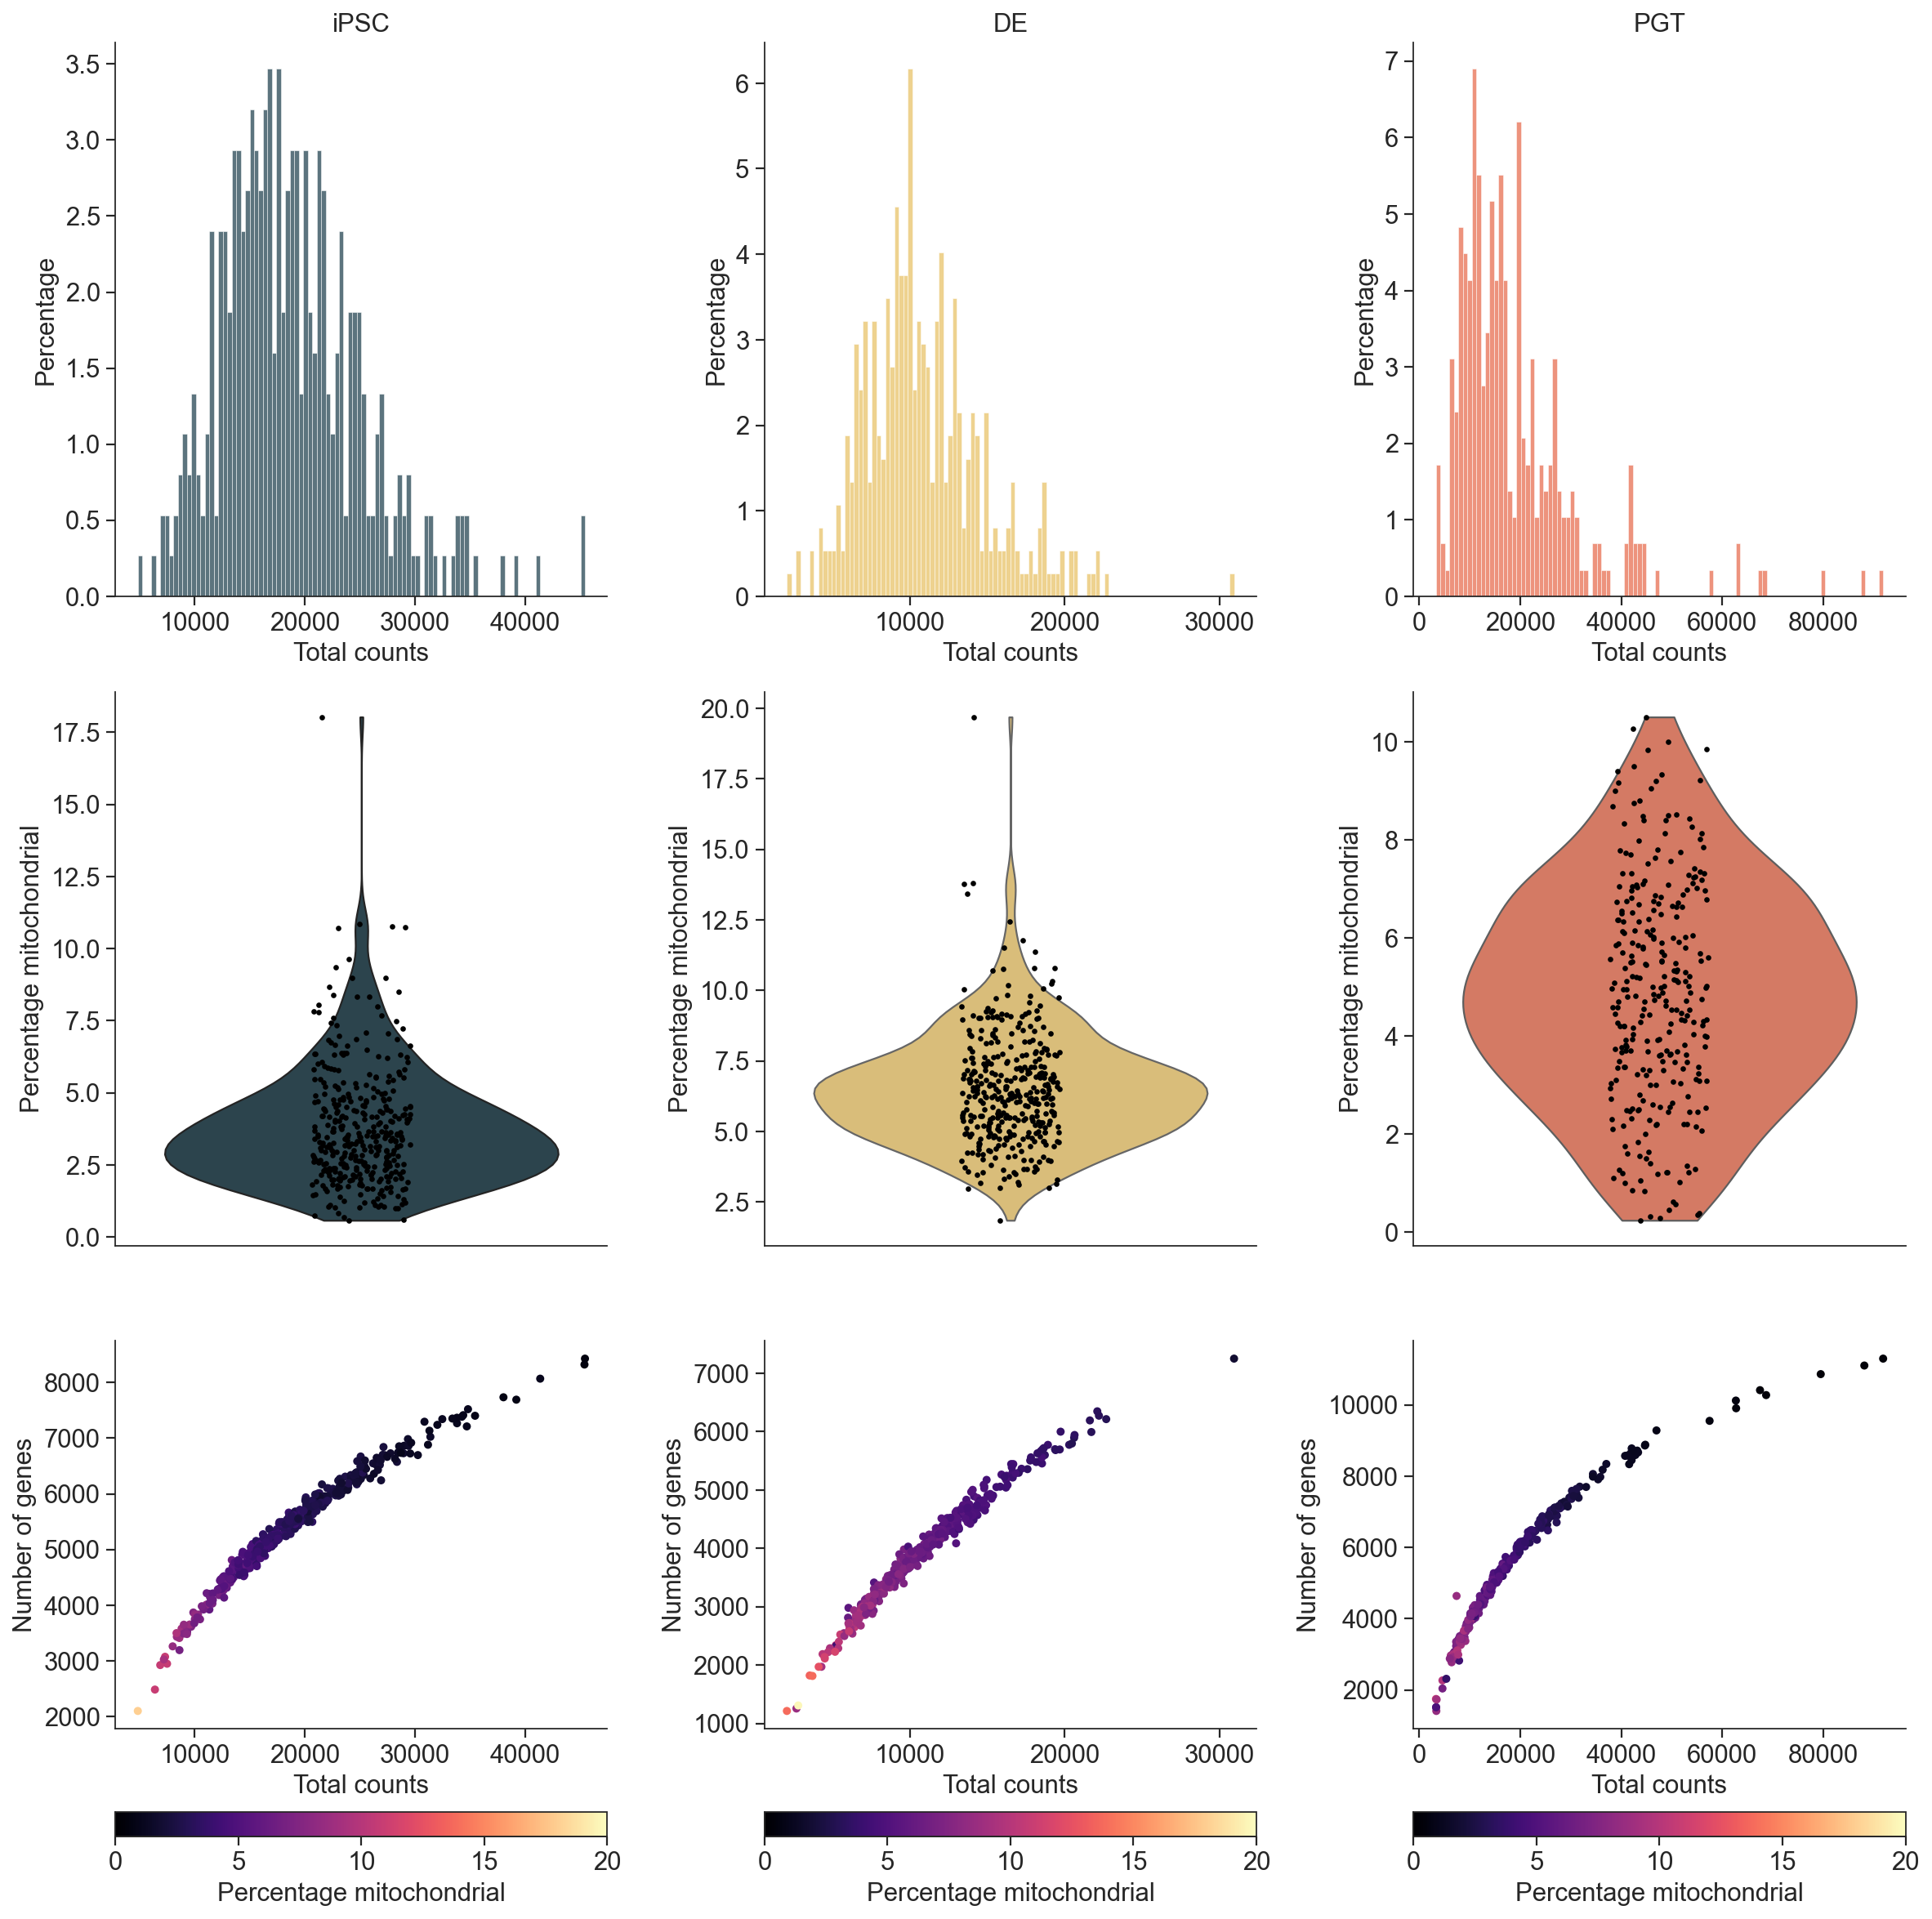

In [4]:
def plot_qc(adatas, labels, colors):
    """Plot QC metrics for multiple AnnData objects in a single figure (one row per sample)."""
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for i, (adata, label, color) in enumerate(zip(adatas, labels, colors)):
        # Total counts
        sns.histplot(adata.obs["total_counts"], bins=100, stat="percent", kde=False, ax=axes[0,i], color=color)
        axes[0,i].set(title=label, xlabel="Total counts", ylabel="Percentage")
        
        # Mitochondrial percentage
        sc.pl.violin(adata, "pct_counts_mt", ax=axes[1,i], show=False, size=3, palette=[color])
        axes[1,i].set(xlabel="", ylabel="Percentage mitochondrial", xticks=[])

        # Total counts vs n_genes colored by mt%
        sc_plot = axes[2,i].scatter(adata.obs["total_counts"], adata.obs["n_genes_by_counts"], 
                                    c=adata.obs["pct_counts_mt"], cmap="magma", vmin=0, vmax=20,
                                    s=20, edgecolor="none")
        colorbar = fig.colorbar(sc_plot, ax=axes[2,i], location="bottom", label="Percentage mitochondrial")
        axes[2,i].set(xlabel="Total counts", ylabel="Number of genes")

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_qc(adatas, labels, colors)

GSM9145591_iPSCs	Total cells before filtering: 375
GSM9145591_iPSCs	Number of low-quality cells removed: 5
GSM9145591_iPSCs	Total cells after filtering: 370

GSM9145592_DE	Total cells before filtering: 373
GSM9145592_DE	Number of low-quality cells removed: 6
GSM9145592_DE	Total cells after filtering: 367

GSM9145593_PGT	Total cells before filtering: 290
GSM9145593_PGT	Number of low-quality cells removed: 5
GSM9145593_PGT	Total cells after filtering: 285



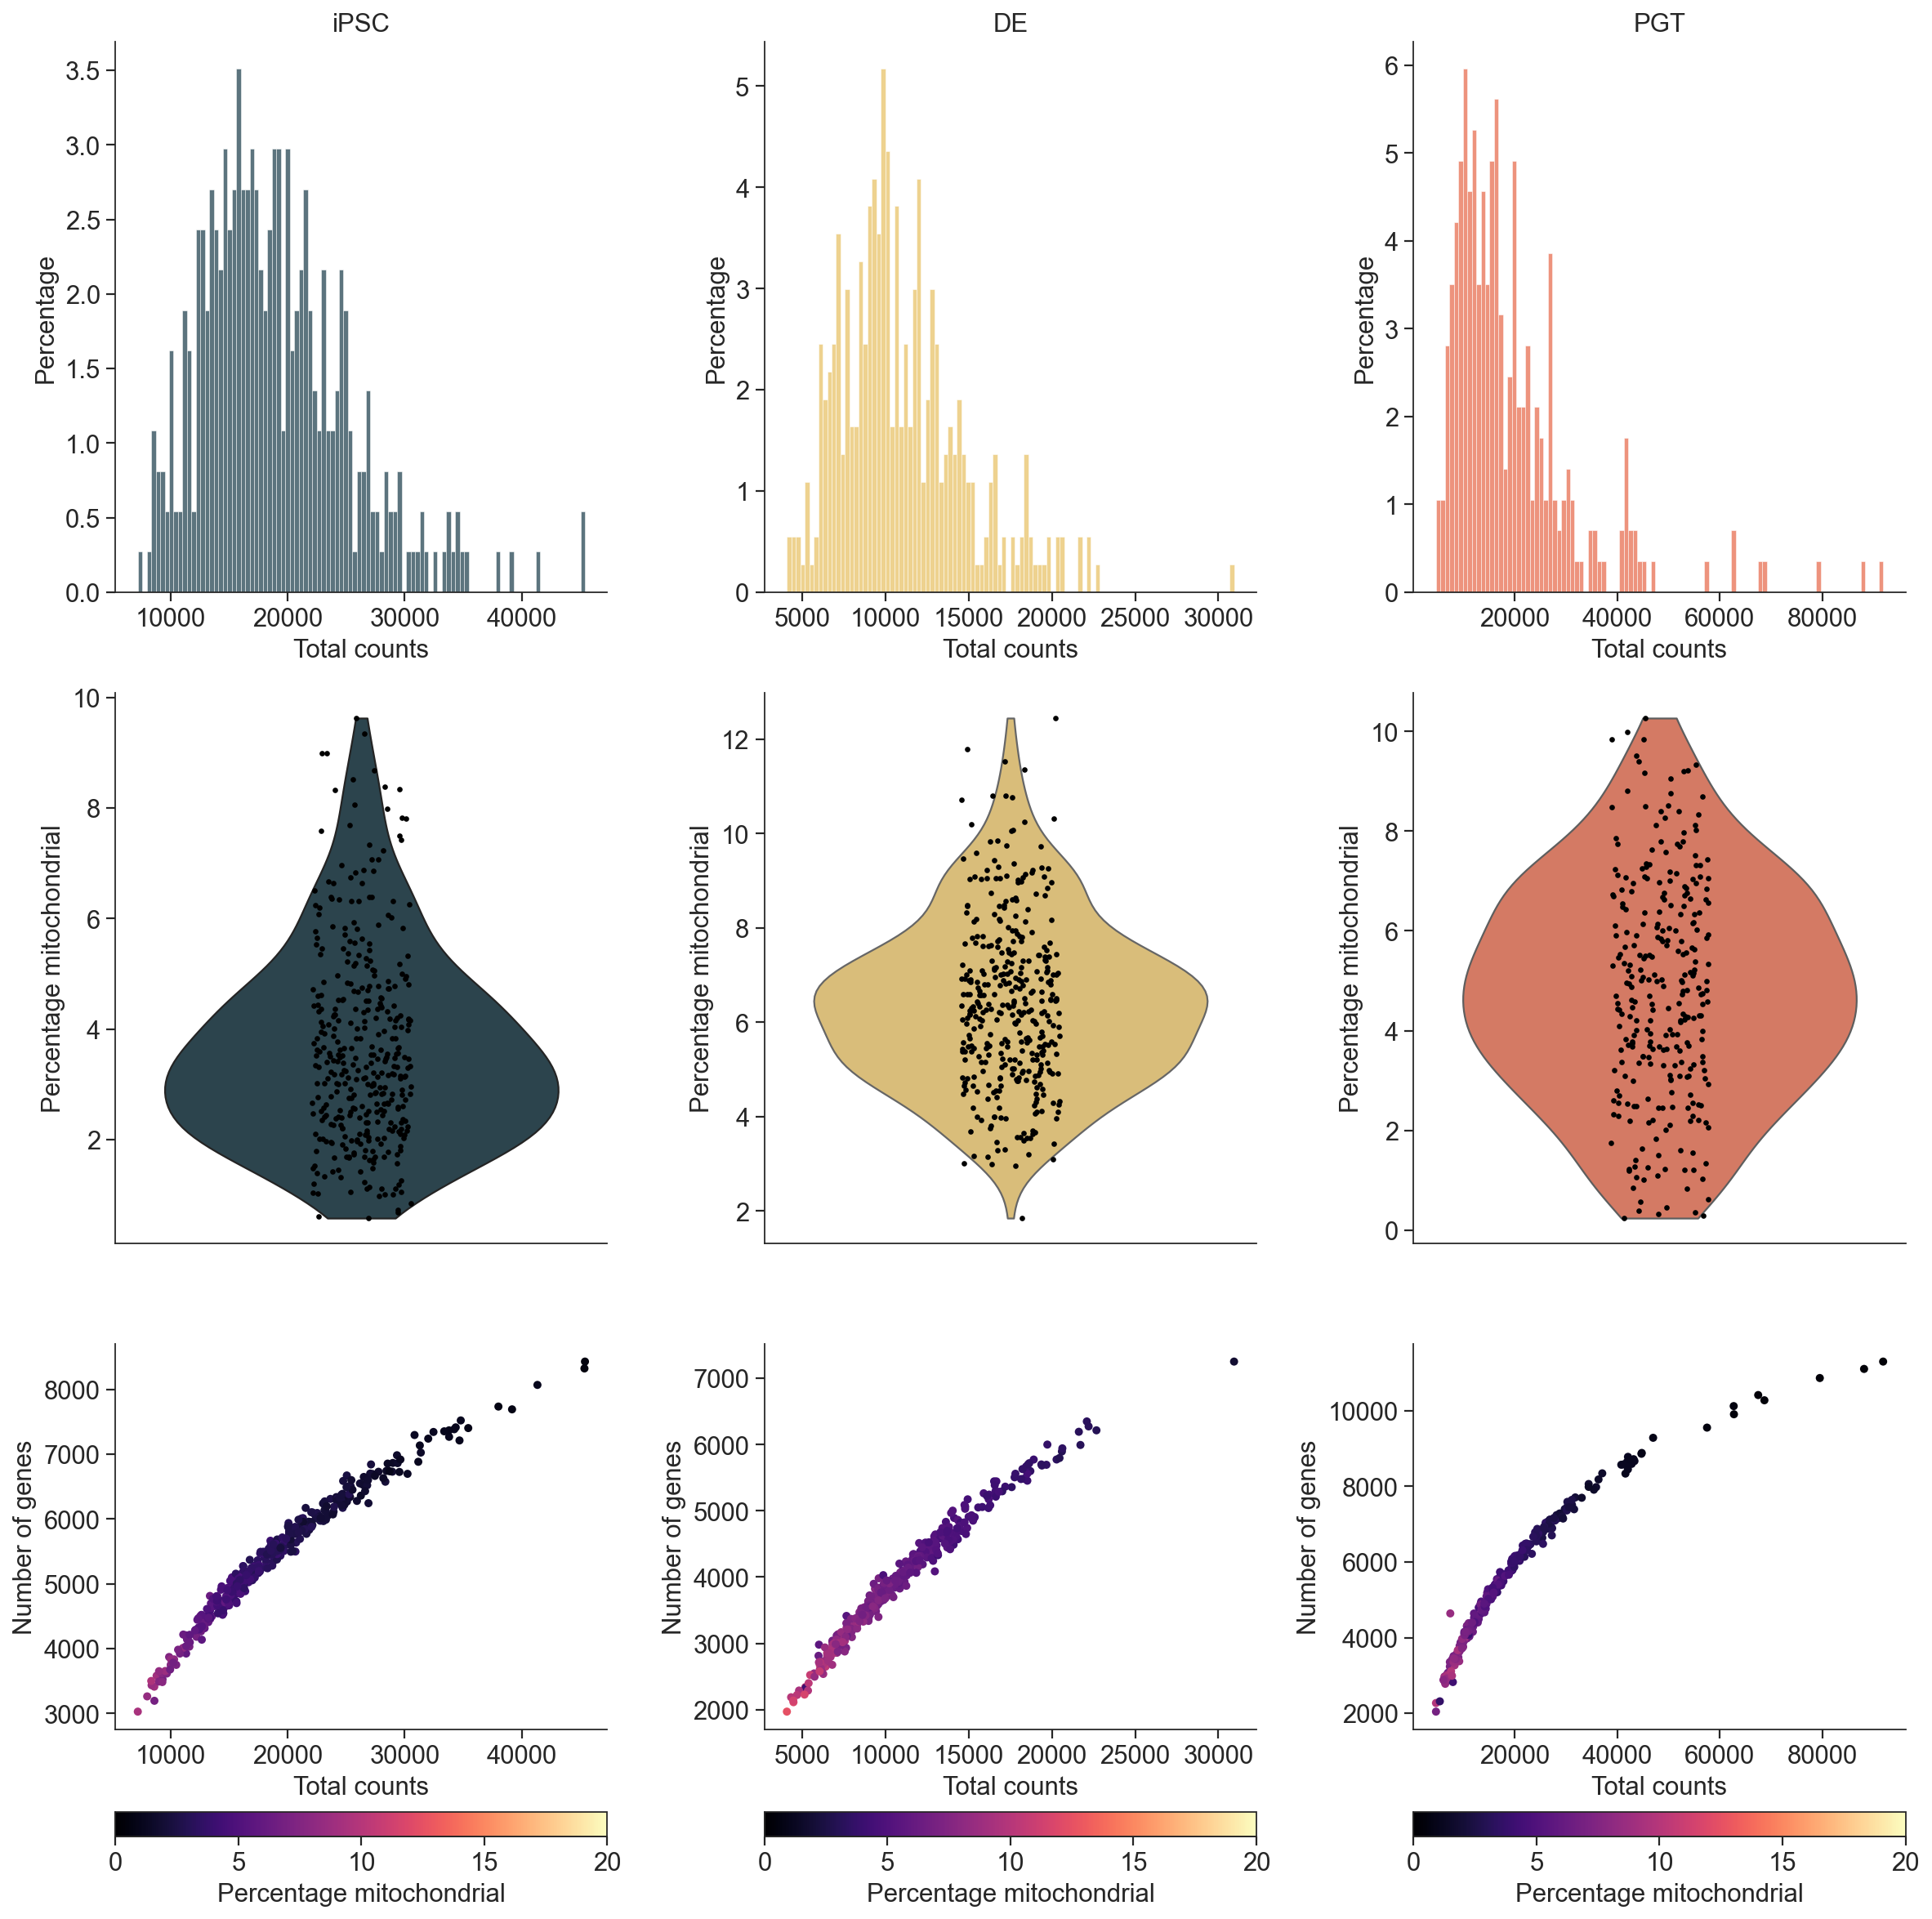

In [5]:
def is_outlier(adata, metric: str, nmads: int):
    """Return a boolean array of cells that are outliers based on median ± nmads * MAD."""
    x = adata.obs[metric]
    med = np.median(x)
    mad = median_abs_deviation(x)
    outlier = (x < med - nmads * mad) | (x > med + nmads * mad)
    return outlier

def filter_outliers(adata, sample):
    """Filter low-quality cells based on multiple outlier metrics."""
    adata.obs["outlier"] = (is_outlier(adata, "log1p_total_counts", 5)
                           | is_outlier(adata, "log1p_n_genes_by_counts", 5)
                           | is_outlier(adata, "pct_counts_in_top_20_genes", 5))
    
    n_outliers = adata.obs["outlier"].sum()
    print(f"{sample}\tTotal cells before filtering: {adata.n_obs}")
    print(f"{sample}\tNumber of low-quality cells removed: {n_outliers}")
    print(f"{sample}\tTotal cells after filtering: {adata.n_obs - n_outliers}\n")

    # Remove low-quality cells
    adata = adata[(~adata.obs.outlier)].copy()
    return adata

adatas = [filter_outliers(adata, sample) for adata, sample in zip(adatas, samples)]
plot_qc(adatas, labels, colors)

## Integration using harmony

In [6]:
for adata, label in zip(adatas, labels):
    counts = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
    counts.to_csv(f"{output_dir}/scRNA.counts_{label}.csv")

In [7]:
count_files = [f"{output_dir}/scRNA.counts_{label}.csv" for label in labels]
counts = harmony.utils.load_from_csvs(count_files, labels)

Loading count matrices...
iPSC
DE
PGT
Concatenating data..


In [8]:
# Normalize, select highly variable genes and log transform
norm_df = harmony.utils.normalize_counts(counts)

hvg_genes = harmony.utils.hvg_genes(norm_df, no_genes=5000)
print(hvg_genes)

data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

Index(['AFP', 'ACTC1', 'NPPB', 'HAPLN1', 'FGB', 'IGLC1', 'PLVAP', 'COL3A1',
       'ACTA1', 'APOA1',
       ...
       'MGAT4B', 'NRBP1', 'NRL', 'LINC02482', 'TMEM222', 'COQ9', 'WDR33',
       'BST1', 'TMEM106B', 'MOCS1'],
      dtype='object', length=5000)


In [9]:
# Prepare meta data for Harmony
meta = pd.Series(index=data_df.index)
for label in labels:
    cells = data_df.index[data_df.index.str.contains(label)]
    meta[cells] = label
display(meta)

connections = pd.DataFrame(np.array([labels[:-1], labels[1:]]).T)
display(connections)

iPSC_AAACAGGC    iPSC
iPSC_AAAGCGGA    iPSC
iPSC_AAAGGCTG    iPSC
iPSC_AACACGCA    iPSC
iPSC_AACATGGG    iPSC
                 ... 
PGT_TTGTCCAC      PGT
PGT_TTGTTCCG      PGT
PGT_TTTGAGGG      PGT
PGT_TTTGTGTC      PGT
PGT_TTTTCGCC      PGT
Length: 1022, dtype: object

,0,1
0,iPSC,DE
1,DE,PGT


In [10]:
aug_aff, aff = harmony.core.augmented_affinity_matrix(data_df, meta, connections)

Running PCA with 583 components
Nearest neighbor computation...
Constucting affinities between iPSC and DE...
t+1 neighbors of t...
t neighbors of t+1...
Constucting affinities between DE and PGT...
t+1 neighbors of t...
t neighbors of t+1...


In [11]:
layout = harmony.plot.force_directed_layout(aug_aff, data_df.index)
display(layout)

layout.to_csv(f"{output_dir}/scRNA.Harmony_layout.txt", sep="\t")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 244.28it/s]

BarnesHut Approximation  took  0.68  seconds
Repulsion forces  took  1.11  seconds
Gravitational forces  took  0.01  seconds
Attraction forces  took  0.11  seconds
AdjustSpeedAndApplyForces step  took  0.08  seconds


,x,y
iPSC_AAACAGGC,-689.754194,1676.738241
iPSC_AAAGCGGA,-606.407838,1415.942161
iPSC_AAAGGCTG,-618.472116,1331.015995
iPSC_AACACGCA,-774.651463,1421.904858
iPSC_AACATGGG,-296.777356,1262.603950
...,...,...
PGT_TTGTCCAC,-731.550779,-1749.311931
PGT_TTGTTCCG,-511.448482,-1934.232199
PGT_TTTGAGGG,-854.466738,-1617.996554
PGT_TTTGTGTC,-259.512837,-2016.805772


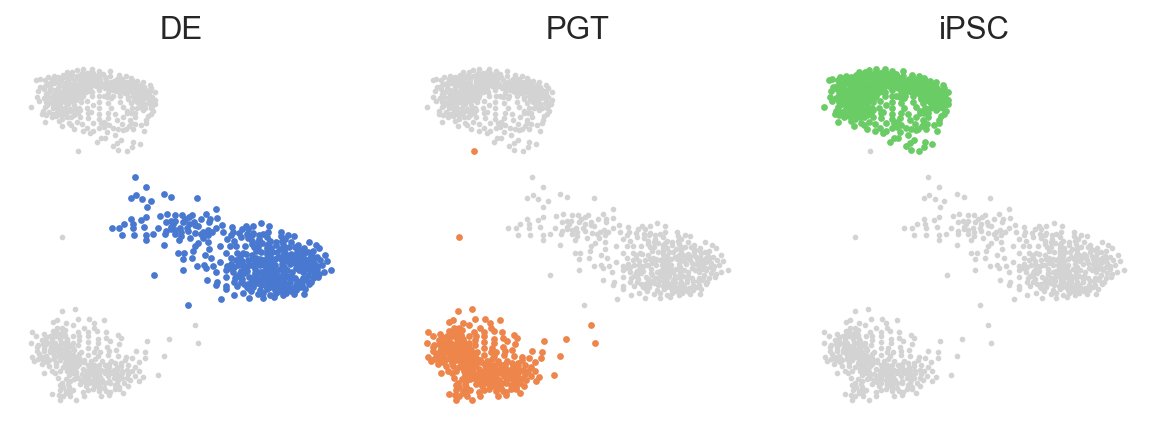

In [12]:
harmony.plot.plot_timepoints(layout, meta)

## Figure 2c: Harmony layout

The Harmony layout will vary across independent script runs. You must choose one of the following files to load the coordinates for visualization:

- Current run: scRNA.Harmony_layout.txt (newly generated)
- Reference: GSE304235_Harmony_layout.txt (manuscript data from GEO)

Uncomment the specific loading command below that corresponds to your choice.

In [13]:
# Load Harmony layout

# Newly generated coordinates
#coordinates = pd.read_csv(f"{output_dir}/scRNA.Harmony_layout.txt", sep="\t", index_col=0, header=0)

# Manuscript coordinates
coordinates = pd.read_csv(f"{input_dir}/GSE304235_Harmony_layout.txt", sep="\t", index_col=0, header=0)

# Convert cell IDs to format used in scanpy
coordinates["barcode"] =  coordinates.index
coordinates[["celltype", "barcode"]] = coordinates["barcode"].str.split("_", expand=True)
coordinates.index = coordinates["barcode"] + "-" + coordinates["celltype"]
coordinates = coordinates.drop(columns=["celltype", "barcode"])

display(coordinates)

,x,y
AAACAGGC-iPSC,-200.080102,1627.923813
AAAGCGGA-iPSC,-364.884937,1520.947949
AAAGGCTG-iPSC,-387.335289,1323.738760
AACACGCA-iPSC,163.520560,1531.904782
AACATGGG-iPSC,-388.420473,1220.438880
...,...,...
TTGTCCAC-PGT,-1114.963720,-1772.201630
TTGTTCCG-PGT,-887.464244,-2011.898900
TTTGAGGG-PGT,-1203.915994,-1650.819403
TTTGTGTC-PGT,-713.477760,-2116.235315


In [14]:
# Merge scanpy objects
adata = adatas[0].concatenate(adatas[1:], batch_key="Celltype", batch_categories=labels)
adata.var_names_make_unique()
adata.obs["Celltype"] = adata.obs["Celltype"].cat.reorder_categories(labels)
print(adata)

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC'


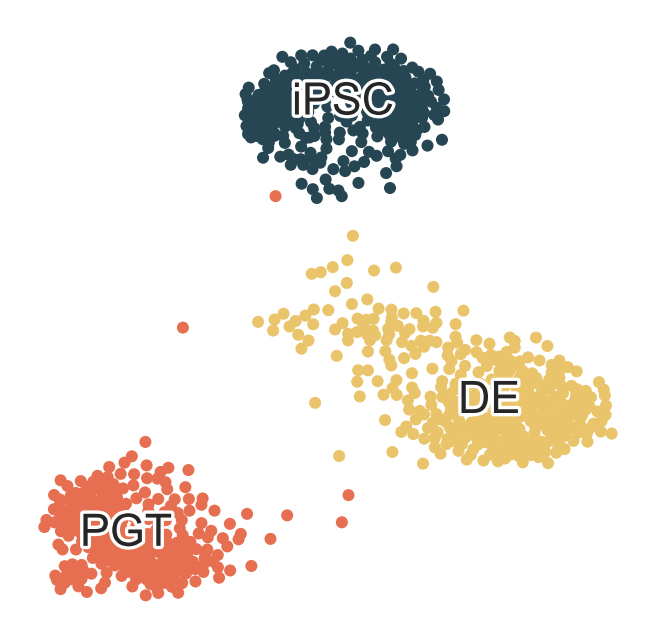

In [15]:
# Add Harmony layout to scanpy object
coordinates = coordinates.loc[adata.obs.index]
adata.obsm["Harmony"] = coordinates.values

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="", show=False,
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3)
    plt.savefig(f"{output_dir}/Figure2c.svg", format="svg")
    plt.show()

## Normalized counts

In [16]:
# Calculate CPM
adata.layers["counts"] = adata.X.copy()
counts_sum = np.array(adata.X.sum(axis=1)).flatten()  # total counts per cell
adata.X = adata.X / counts_sum[:, None] * 1e6         # scale to CPM
adata.layers["CPM"] = adata.X.copy()

In [17]:
# Normalize scanpy object
adata.X = adata.layers["counts"]
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata)

## Save scanpy object

In [25]:
adata.layers["counts"] = adata.layers["counts"].tocsr()
adata.layers["CPM"] = adata.layers["CPM"].tocsr()
display(adata)

adata.write_h5ad(f"{output_dir}/scRNA.h5ad")

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'Celltype'
    obsm: 'Harmo